In [ ]:
# =========================================
# PATH
# =========================================
data_root = "/content/drive/MyDrive/Teeth_Dataset"
MODEL_SAVE_PATH = "/content/drive/MyDrive/teeth.pth"


In [ ]:
# =========================================
# IMPORTS
# =========================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import timm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import label_binarize

In [ ]:

# =========================================
# TRANSFORMS (slightly improved)
# =========================================
transform_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomResizedCrop(224, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.3,0.3,0.3,0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [ ]:
# DATASETS
# =========================================
train_dataset = datasets.ImageFolder(f"{data_root}/Training", transform=transform_train)
val_dataset   = datasets.ImageFolder(f"{data_root}/Validation", transform=transform_test)
test_dataset  = datasets.ImageFolder(f"{data_root}/Testing", transform=transform_test)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)


Classes: ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']


In [ ]:
# =========================================
# WEIGHTED SAMPLER
# =========================================
targets = [label for _, label in train_dataset]
class_counts = np.bincount(targets)

class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in targets]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)


In [ ]:
# =========================================
# MODEL (UNCHANGED)
# =========================================
class EfficientNetBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        base = torchvision.models.efficientnet_b0(pretrained=True)
        self.features = base.features

    def forward(self,x):
        x = self.features[0](x)
        x = self.features[1](x)
        F1 = self.features[2](x)
        F2 = self.features[3](F1)
        F3 = self.features[4:](F2)
        return F1,F2,F3

class ViTBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=0)

    def forward(self,x):
        tokens = self.vit.forward_features(x)
        return tokens[:,0]

class FeatureFusionAttention(nn.Module):
    def __init__(self, cnn_dim, vit_dim, num_classes):
        super().__init__()

        fused_dim = cnn_dim + vit_dim

        # auxiliary heads (keep this from your design)
        self.cnn_aux = nn.Linear(cnn_dim, num_classes)
        self.vit_aux = nn.Linear(vit_dim, num_classes)

        # projection after concat
        self.proj = nn.Linear(fused_dim, 512)

        # attention block (THIS is the key)
        self.attn_dense = nn.Linear(512, 128)
        self.attn_score = nn.Linear(128, 512)

    def forward(self, h_cnn, h_vit):

        # aux logits
        cnn_logits = self.cnn_aux(h_cnn)
        vit_logits = self.vit_aux(h_vit)

        # ===== FEATURE CONCAT =====
        fused = torch.cat([h_cnn, h_vit], dim=1)

        # ===== PROJECTION =====
        fused = F.relu(self.proj(fused))   # [B, 512]

        # ===== ATTENTION BLOCK =====
        attn = F.relu(self.attn_dense(fused))     # [B,128]
        attn = self.attn_score(attn)              # [B,512]
        attn = F.softmax(attn, dim=1)             # normalize

        # apply attention
        fused = fused * attn
        return fused, cnn_logits, vit_logits

class OrCanNet(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.cnn = EfficientNetBackbone()
        self.vit = ViTBranch()
        self.fusion = FeatureFusionAttention(1280,384,num_classes)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(512,num_classes)

    def forward(self,x):
        _,_,F3 = self.cnn(x)
        h_cnn = torch.flatten(F.adaptive_avg_pool2d(F3,1),1)
        h_vit = self.vit(x)

        fused,cnn_logits,vit_logits = self.fusion(h_cnn,h_vit)

        fused = self.dropout(fused)
        out = self.classifier(fused)

        return out,cnn_logits,vit_logits

In [ ]:
# =========================================
# DEVICE
# =========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = OrCanNet(num_classes).to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 184MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

In [ ]:

# =========================================
# FREEZE FUNCTIONS
# =========================================
def freeze_backbone(model):
    for param in model.cnn.parameters():
        param.requires_grad = False
    for param in model.vit.parameters():
        param.requires_grad = False

def unfreeze_backbone(model):
    for param in model.cnn.parameters():
        param.requires_grad = True
    for param in model.vit.parameters():
        param.requires_grad = True

In [ ]:
# =========================================
# LOSS (WEIGHTED)
# =========================================
weights = torch.tensor(1.0 / class_counts, dtype=torch.float).to(device)

lambda_aux = 0.1

def compute_loss(out,cnn_logits,vit_logits,labels):
    main = F.cross_entropy(out,labels,weight=weights,label_smoothing=0.1)
    aux1 = F.cross_entropy(cnn_logits,labels,weight=weights)
    aux2 = F.cross_entropy(vit_logits,labels,weight=weights)
    return main + lambda_aux*(aux1 + aux2)


In [ ]:
# =========================================
# EARLY STOPPING
# =========================================
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best = 0
        self.stop = False

    def __call__(self, val_acc):
        if val_acc > self.best:
            self.best = val_acc
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

In [ ]:
# =========================================
# TRAINING SETUP
# =========================================
freeze_backbone(model)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-4,
    weight_decay=1e-4
)

epochs = 50
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

early_stopper = EarlyStopping()
best_acc = 0

In [ ]:
train_losses = []
val_accuracies = []

for epoch in range(epochs):

    if epoch == 5:
        print("🔓 Unfreezing backbone...")
        unfreeze_backbone(model)

        optimizer = torch.optim.AdamW([
            {"params": model.cnn.parameters(), "lr": 1e-5},
            {"params": model.vit.parameters(), "lr": 1e-5},
            {"params": model.fusion.parameters(), "lr": 3e-5},
            {"params": model.classifier.parameters(), "lr": 3e-5},
        ], weight_decay=1e-4)

    model.train()
    train_loss = 0

    # 🔁 TRAIN LOOP
    for images,labels in train_loader:
        images,labels = images.to(device),labels.to(device)

        optimizer.zero_grad()

        out,cnn_logits,vit_logits = model(images)
        loss = compute_loss(out,cnn_logits,vit_logits,labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimizer.step()

        train_loss += loss.item()

    scheduler.step()

    # 🔁 VALIDATION
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images,labels in val_loader:
            images,labels = images.to(device),labels.to(device)

            out,_,_ = model(images)
            preds = torch.argmax(out,1)

            correct += (preds==labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    # ✅ NOW store metrics (correct place)
    train_losses.append(train_loss / len(train_loader))
    val_accuracies.append(val_acc)

    # PRINT
    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss/len(train_loader):.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")
    print("-"*40)

    # SAVE BEST
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print("✅ Best model saved")

    early_stopper(val_acc)
    if early_stopper.stop:
        print("🛑 Early stopping triggered")
        break

Epoch 1
Train Loss: 2.2253
Validation Accuracy: 0.3395
----------------------------------------
✅ Best model saved
Epoch 2
Train Loss: 1.8987
Validation Accuracy: 0.4805
----------------------------------------
✅ Best model saved
Epoch 3
Train Loss: 1.6863
Validation Accuracy: 0.5788
----------------------------------------
✅ Best model saved
Epoch 4
Train Loss: 1.5804
Validation Accuracy: 0.6887
----------------------------------------
✅ Best model saved
Epoch 5
Train Loss: 1.5029
Validation Accuracy: 0.7374
----------------------------------------
✅ Best model saved
🔓 Unfreezing backbone...
Epoch 6
Train Loss: 1.3739
Validation Accuracy: 0.7870
----------------------------------------
✅ Best model saved
Epoch 7
Train Loss: 1.2868
Validation Accuracy: 0.8667
----------------------------------------
✅ Best model saved
Epoch 8
Train Loss: 1.2013
Validation Accuracy: 0.9008
----------------------------------------
✅ Best model saved
Epoch 9
Train Loss: 1.1293
Validation Accuracy: 0.9329


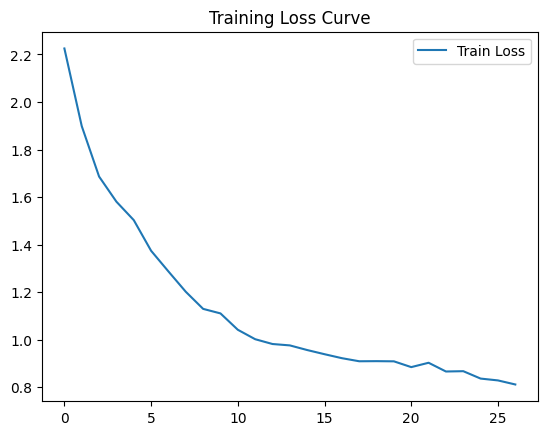

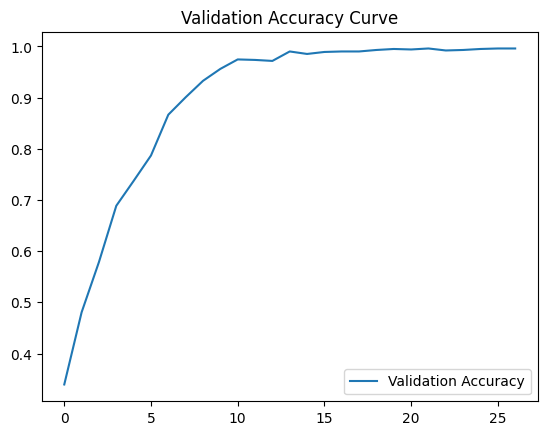

In [ ]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.show()

plt.figure()
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Validation Accuracy Curve")
plt.legend()
plt.show()

              precision    recall  f1-score   support

         CaS       0.99      1.00      1.00       160
         CoS       0.99      1.00      1.00       149
         Gum       1.00      1.00      1.00       120
          MC       0.99      0.99      0.99       180
          OC       0.99      0.98      0.99       108
         OLP       1.00      0.99      1.00       180
          OT       1.00      1.00      1.00       131

    accuracy                           1.00      1028
   macro avg       1.00      0.99      1.00      1028
weighted avg       1.00      1.00      1.00      1028



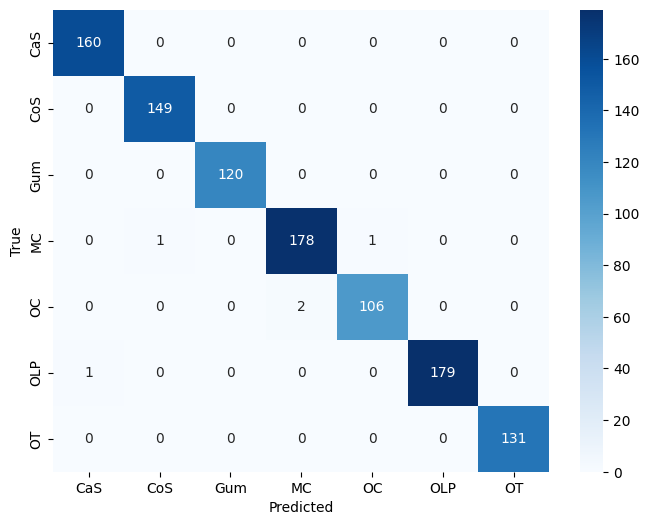

In [ ]:

# =========================================
# TEST EVALUATION
# =========================================
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images,labels in test_loader:
        images = images.to(device)
        out,_,_ = model(images)
        preds = torch.argmax(out,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images,labels in test_loader:
        images = images.to(device)

        out,_,_ = model(images)

        probs = torch.softmax(out, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

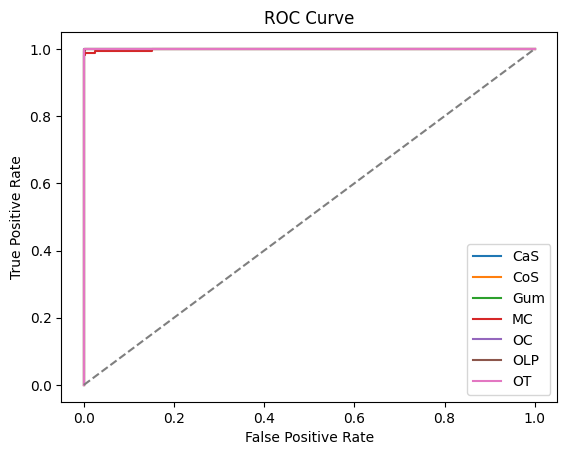

ROC-AUC: 0.9998520585656558


In [ ]:
y_true_bin = label_binarize(all_labels, classes=list(range(num_classes)))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=class_names[i])

plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

roc_auc = roc_auc_score(y_true_bin, all_probs, multi_class='ovr')
print("ROC-AUC:", roc_auc)

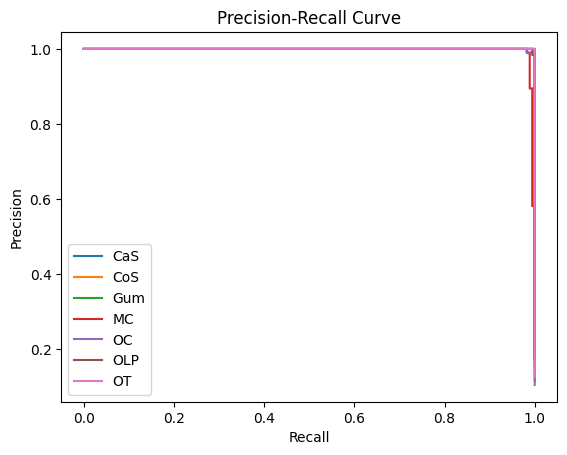

In [ ]:
plt.figure()
for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], all_probs[:, i])
    plt.plot(recall, precision, label=class_names[i])

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

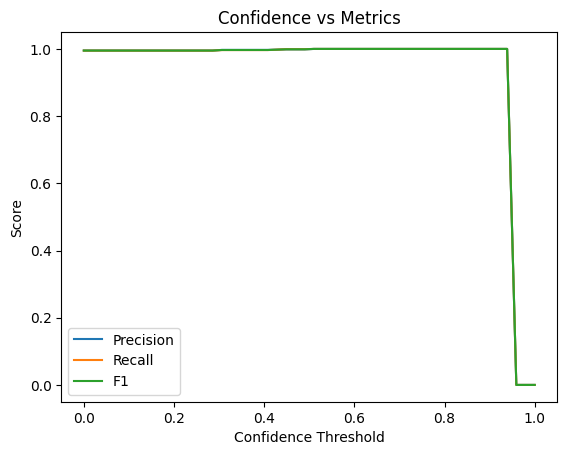

In [ ]:
thresholds = np.linspace(0,1,50)

precisions = []
recalls = []
f1s = []

conf = all_probs.max(axis=1)

for t in thresholds:
    idx = conf >= t

    if np.sum(idx) == 0:
        precisions.append(0)
        recalls.append(0)
        f1s.append(0)
        continue

    p = precision_score(all_labels[idx], all_preds[idx], average='macro', zero_division=0)
    r = recall_score(all_labels[idx], all_preds[idx], average='macro', zero_division=0)
    f1 = f1_score(all_labels[idx], all_preds[idx], average='macro', zero_division=0)

    precisions.append(p)
    recalls.append(r)
    f1s.append(f1)

plt.figure()
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f1s, label="F1")
plt.title("Confidence vs Metrics")
plt.xlabel("Confidence Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()